# Proyecto - Implementación Fase 1
- Fabiola Contreras -22787
- María Villafuerte -22129

## Dataset utilizado

### Kaggle - Benign and Malicious QR Code
Es un dataset ya preparado con imágenes de códigos QR balanceados (benignos y maliciosos). Ha sido usado en investigaciones recientes.

In [26]:
# Descargar dataset
# !kaggle datasets download -d samahsadiq/benign-and-malicious-qr-codes

In [27]:
import os
# Explorar estructura del dataset de Kaggle
kaggle_path = 'data/kaggle-qr-codes'

print("ESTRUCTURA DEL DATASET")
for root, dirs, files in os.walk(kaggle_path):
    level = root.replace(kaggle_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Mostrar solo primeros 5 archivos
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... y {len(files)-5} archivos más")

ESTRUCTURA DEL DATASET
kaggle-qr-codes/
  QR codes/
    benign/
      benign/
        benign_0.png
        benign_1.png
        benign_10.png
        benign_100.png
        benign_1000.png
        ... y 99995 archivos más
    malicious/
      malicious/
        malicious_316254.png
        malicious_316255.png
        malicious_316256.png
        malicious_316257.png
        malicious_316258.png
        ... y 99995 archivos más


### GitHub - Detecting Quishing Attacks
Dataset con información de 9,987 códigos QR (69x69 píxeles) como numpy arrays. Listo para procesamiento

In [28]:
# Clonar repositorio
# !git clone https://github.com/fouadtrad/Detecting-Quishing-Attacks-with-Machine-Learning-Techniques-Through-QR-Code-Analysis.git

# O descargar directamente el ZIP desde GitHub

## Análisis exploratorio
Identificación de características clave

In [29]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Leer CSV
df = pd.read_csv('data_procesada/qr_full_dataset.csv')

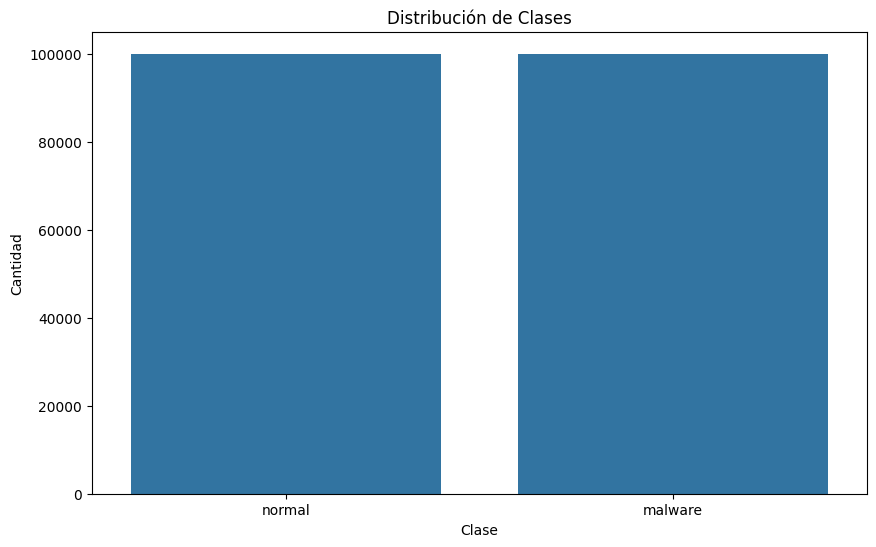

In [31]:
# Distribución de clases
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label_name')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

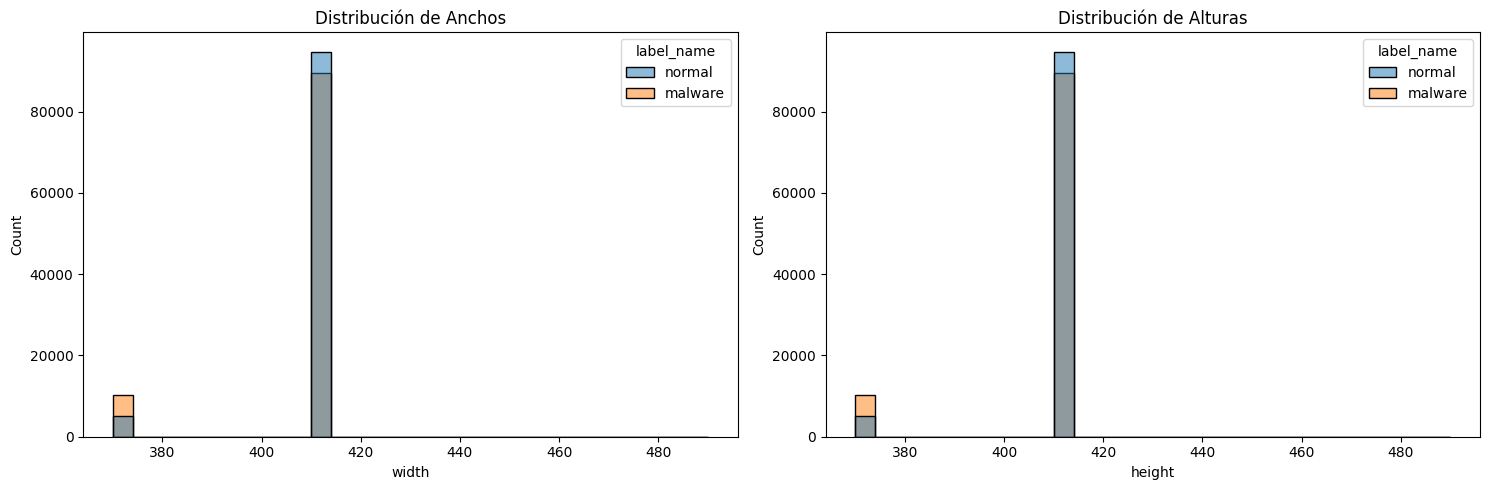

In [32]:
# Distribución de tamaños
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='width', hue='label_name', ax=axes[0], bins=30)
axes[0].set_title('Distribución de Anchos')

sns.histplot(data=df, x='height', hue='label_name', ax=axes[1], bins=30)
axes[1].set_title('Distribución de Alturas')

plt.tight_layout()
plt.show()

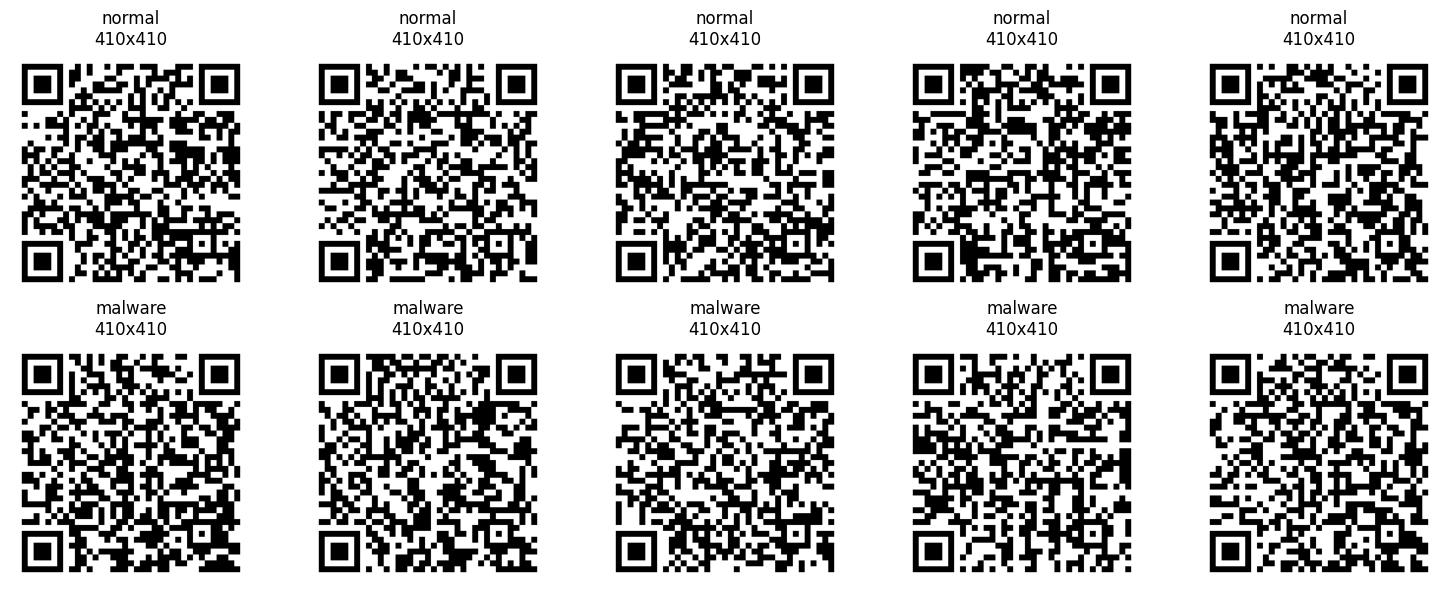

In [33]:
# Visualizar muestras
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, label in enumerate(['normal', 'malware']):
    samples = df[df['label_name'] == label].sample(5)
    
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath'])
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(f"{label}\n{row['width']}x{row['height']}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [34]:
# Estadísticas básicas
print("ESTADÍSTICAS DEL DATASET ")
print(df.describe())

ESTADÍSTICAS DEL DATASET 
               label          width         height      mode     size_bytes
count  200000.000000  200000.000000  200000.000000  200000.0  200000.000000
mean        1.000000     406.888600     406.888600       1.0     927.905195
std         1.000003      10.733488      10.733488       0.0      46.415487
min         0.000000     370.000000     370.000000       1.0     708.000000
25%         0.000000     410.000000     410.000000       1.0     916.000000
50%         1.000000     410.000000     410.000000       1.0     937.000000
75%         2.000000     410.000000     410.000000       1.0     956.000000
max         2.000000     490.000000     490.000000       1.0    1234.000000


In [35]:
print("INFO DEL DATASET")
print(df.info())

INFO DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   filepath    200000 non-null  object
 1   filename    200000 non-null  object
 2   label       200000 non-null  int64 
 3   label_name  200000 non-null  object
 4   width       200000 non-null  int64 
 5   height      200000 non-null  int64 
 6   mode        200000 non-null  int64 
 7   size_bytes  200000 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 12.2+ MB
None


## Características a utilizar
Generación y selección